# Figures

## Chop/Nod schematic

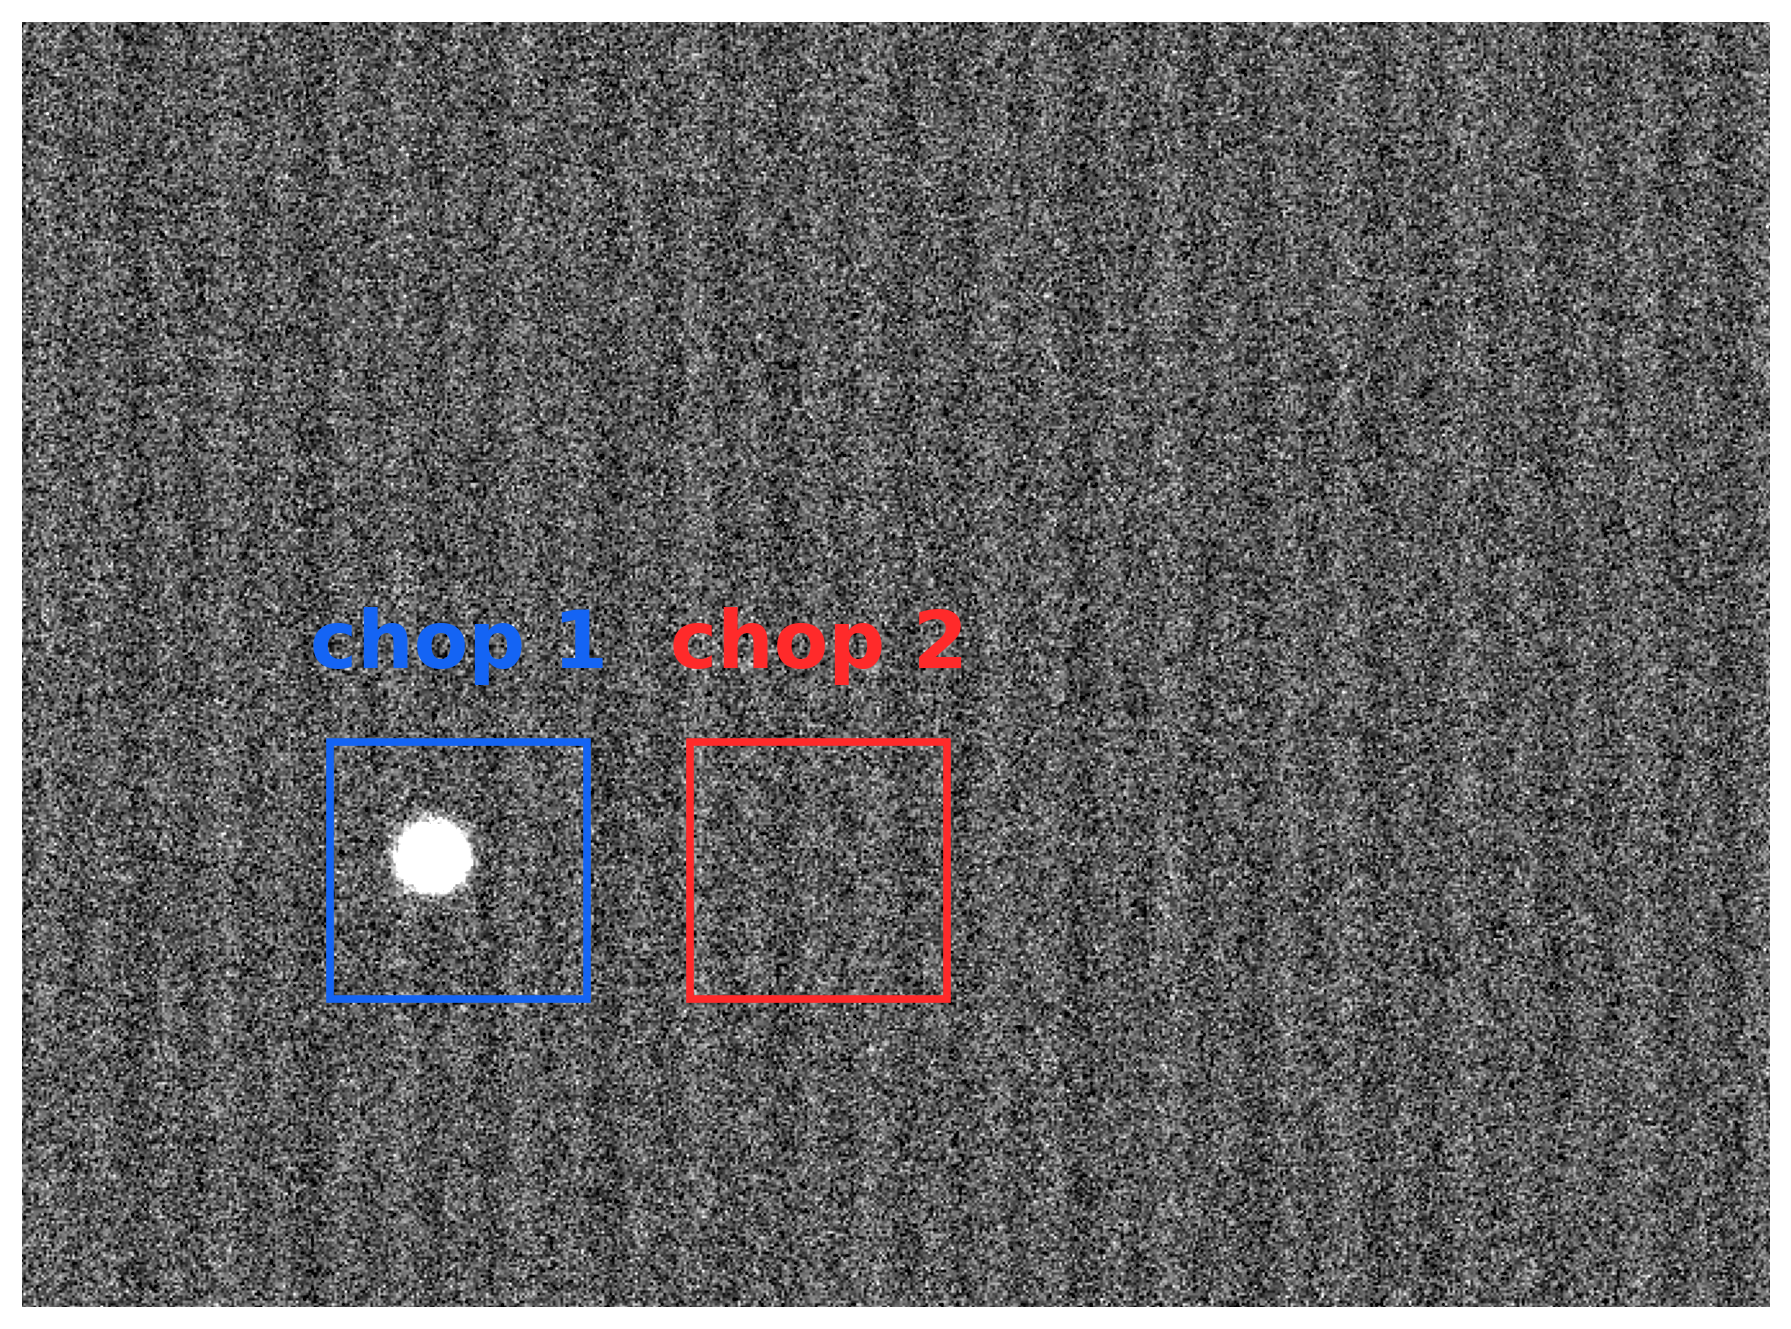

In [2]:
# Figure Generation for 699 project 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

rng = np.random.default_rng(42)

# Image size
ny, nx = 1024, 1024
y, x = np.mgrid[0:ny, 0:nx]

# Background: Gaussian noise + a mild detector-like column pattern
background = rng.normal(loc=0.0, scale=1.0, size=(ny, nx))
column_pattern = 0.20 * np.sin(2 * np.pi * x / 23.0) + 0.08 * np.sin(2 * np.pi * x / 61.0)
image = background + column_pattern

def gaussian_2d(x, y, x0, y0, sigma, amp):
    return amp * np.exp(-((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma**2))

# Rectangle geometry
rect_w = 100
rect_h = 100

# Chop positions
chop1_xy = (300, 380)   # lower-left corner of chop 1 rectangle
gap = 40
chop2_xy = (chop1_xy[0] + rect_w + gap, chop1_xy[1])

# Put one point source in each chop position
src1 = (chop1_xy[0] + rect_w // 2 - 10, chop1_xy[1] + rect_h // 2 + 5)
#src2 = (chop2_xy[0] + rect_w // 2 + 5, chop2_xy[1] + rect_h // 2 + 5)

# Add simulated point sources
image += gaussian_2d(x, y, src1[0], src1[1], sigma=6.0, amp=50.0)
#image += gaussian_2d(x, y, src2[0], src2[1], sigma=6.0, amp=70.0)

# Display limits
vmin = np.percentile(image, 5)
vmax = np.percentile(image, 99.8)

fig, ax = plt.subplots(figsize=(8, 8), dpi=220)
ax.imshow(image, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)

blue = "#1464F4"
red = "#FF2A2A"

ax.add_patch(Rectangle(chop1_xy, rect_w, rect_h, fill=False, ec=blue, lw=2.5))
ax.add_patch(Rectangle(chop2_xy, rect_w, rect_h, fill=False, ec=red, lw=2.5))

ax.text(
    chop1_xy[0] + rect_w / 2,
    chop1_xy[1] + rect_h + 22,
    "chop 1",
    color=blue,
    fontsize=26,
    fontweight="bold",
    ha="center",
    va="bottom",
)
ax.text(
    chop2_xy[0] + rect_w / 2,
    chop2_xy[1] + rect_h + 22,
    "chop 2",
    color=red,
    fontsize=26,
    fontweight="bold",
    ha="center",
    va="bottom",
)

# Optional crop for publication-style framing
ax.set_xlim(180, 860)
ax.set_ylim(260, 760)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout(pad=0.2)
#plt.savefig("chop_demo_python.png", bbox_inches="tight", pad_inches=0.02)
#plt.savefig("chop_demo_python.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

## H (Absolute Magnitude)

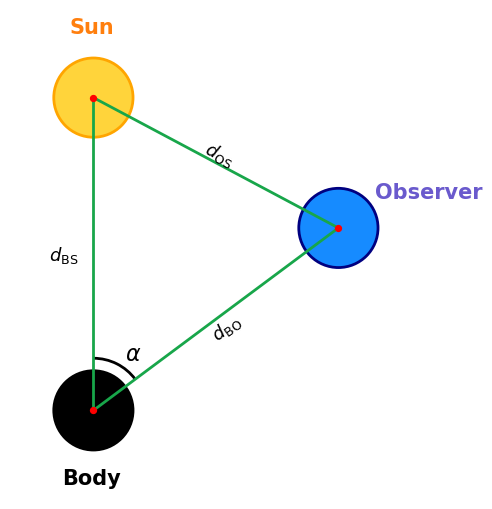

'/mnt/data/phase_angle_geometry_python.png'

In [5]:

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Arc
import numpy as np

# --- Geometry ---
sun = np.array([0.0, 3.0])
body = np.array([0.0, 0.0])
observer = np.array([2.35, 1.75])

fig, ax = plt.subplots(figsize=(5.2, 5.2))

# Colors
sun_color = "#FFD43B"
body_color = "black"
obs_color = "#168BFF"
line_color = "#18A64A"

# Draw connecting lines
ax.plot([body[0], sun[0]], [body[1], sun[1]], color=line_color, lw=2)
ax.plot([body[0], observer[0]], [body[1], observer[1]], color=line_color, lw=2)
ax.plot([sun[0], observer[0]], [sun[1], observer[1]], color=line_color, lw=2)

# Draw bodies
sun_circle = Circle(sun, 0.38, facecolor=sun_color, edgecolor="orange", lw=2)
body_circle = Circle(body, 0.38, facecolor=body_color, edgecolor="black", lw=2)
obs_circle = Circle(observer, 0.38, facecolor=obs_color, edgecolor="navy", lw=2)

for c in [sun_circle, body_circle, obs_circle]:
    ax.add_patch(c)

# Centers
ax.scatter(*sun, color="red", s=18, zorder=5)
ax.scatter(*body, color="red", s=18, zorder=5)
ax.scatter(*observer, color="red", s=18, zorder=5)

# Labels
ax.text(sun[0]-0.02, sun[1]+0.58, "Sun", color="tab:orange",
        ha="center", va="bottom", fontsize=15, fontweight="bold")
ax.text(body[0]-0.02, body[1]-0.55, "Body", color="black",
        ha="center", va="top", fontsize=15, fontweight="bold")
ax.text(observer[0]+0.35, observer[1]+0.34, "Observer", color="slateblue",
        ha="left", va="center", fontsize=15, fontweight="bold")

# Distance labels
ax.text(-0.28, 1.50, r"$d_{\mathrm{BS}}$", color="black",
        ha="center", va="center", fontsize=13, fontweight="bold")

mid_so = (sun + observer) / 2
ax.text(mid_so[0]+0.03, mid_so[1]+0.08, r"$d_{\mathrm{OS}}$", color="black",
        ha="center", va="center", fontsize=13, fontweight="bold",
        rotation=-28)

mid_bo = (body + observer) / 2
ax.text(mid_bo[0]+0.10, mid_bo[1]-0.08, r"$d_{\mathrm{BO}}$", color="black",
        ha="center", va="center", fontsize=13, fontweight="bold",
        rotation=36)

# Phase angle arc at body
theta1 = np.degrees(np.arctan2(sun[1]-body[1], sun[0]-body[0]))
theta2 = np.degrees(np.arctan2(observer[1]-body[1], observer[0]-body[0]))
arc = Arc(body, 1.0, 1.0, angle=0, theta1=theta2, theta2=theta1,
          color="black", lw=2)
ax.add_patch(arc)

# Small alpha label
alpha_pos = body + np.array([0.38, 0.55])
ax.text(alpha_pos[0], alpha_pos[1], r"$\alpha$", fontsize=16,
        ha="center", va="center")

# Formatting
ax.set_aspect("equal")
ax.set_xlim(-0.8, 3.05)
ax.set_ylim(-0.85, 3.85)
ax.axis("off")

plt.tight_layout()
plt.show()

out


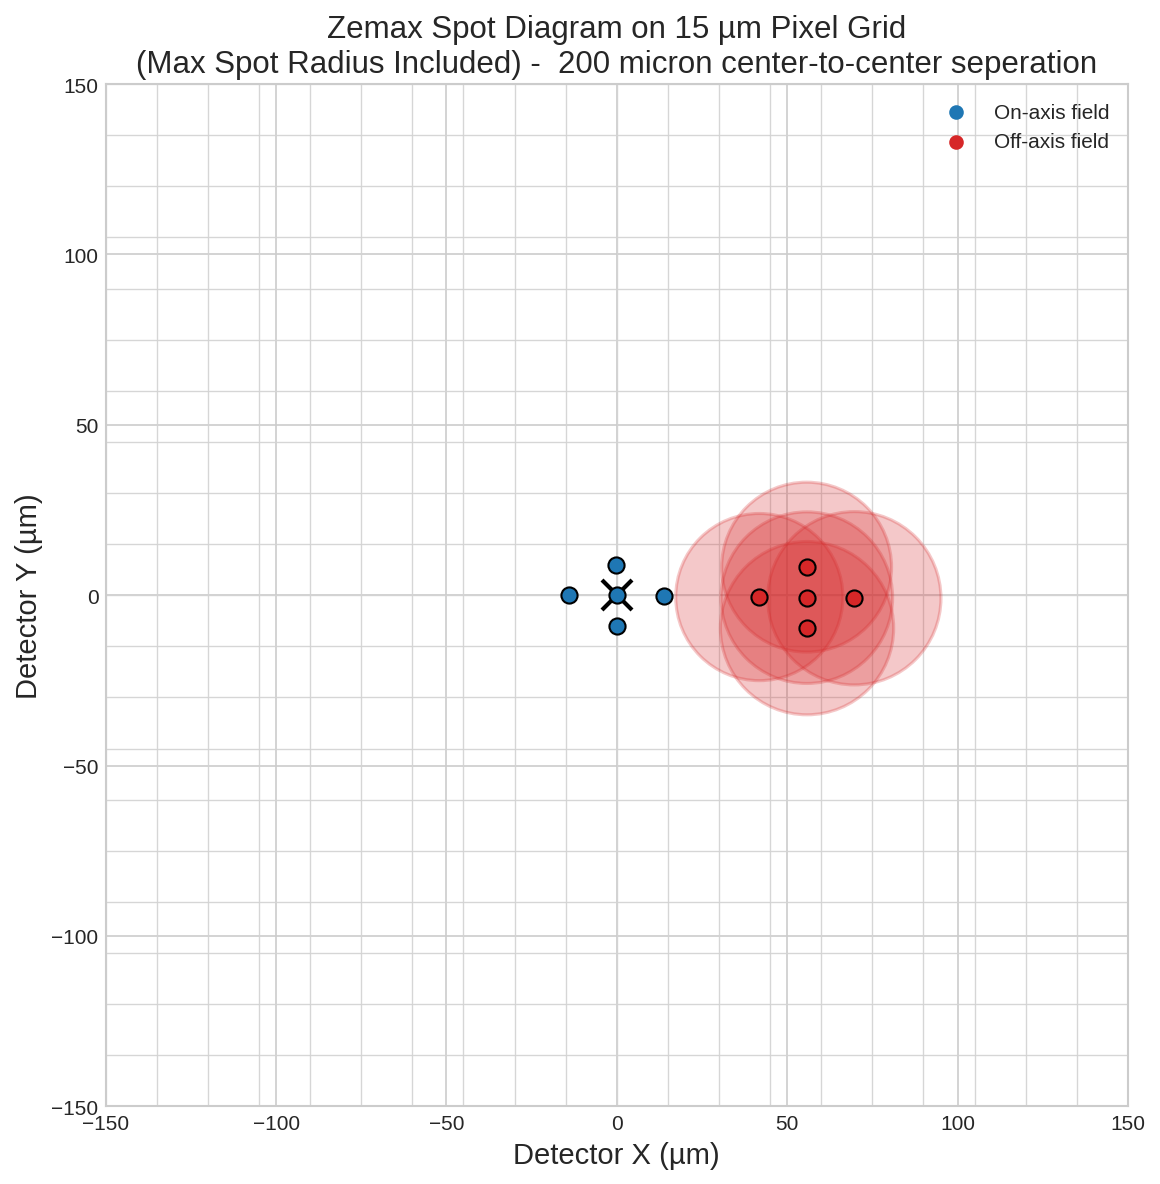

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Rectangle

# ---------------------------------------------------
# Image coordinates (mm)
# ---------------------------------------------------
x = np.array([
    43.7685354,
    43.7824833,
    43.7545847,
    43.7684548,
    43.7686140,
    43.8243094,
    43.8382451,
    43.8103705,
    43.8242476,
    43.8243690
])

y = np.array([
    -21.5025194,
    -21.5026998,
    -21.5023370,
    -21.4935542,
    -21.5114734,
    -21.5032289,
    -21.5034012,
    -21.5030545,
    -21.4942691,
    -21.5121775
])

# ---------------------------------------------------
# Max Spot Radius (µm)
# ---------------------------------------------------
r_um = np.array([
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    25.17669069,
    25.4297197,
    24.5272603,
    24.9279621,
    25.4230401
])

# ---------------------------------------------------
# Field center = first 5 points
# ---------------------------------------------------
xc = np.mean(x[:5])
yc = np.mean(y[:5])

dx = (x - xc) * 1000  # µm
dy = (y - yc) * 1000

# ---------------------------------------------------
# Figure
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(8,8), dpi=150)

# ---------------------------------------------------
# Pixel grid (15 µm)
# ---------------------------------------------------
pixel = 15
grid_lim = 150

for i in range(-grid_lim, grid_lim, pixel):
    for j in range(-grid_lim, grid_lim, pixel):
        ax.add_patch(Rectangle(
            (i, j),
            pixel,
            pixel,
            facecolor='none',
            edgecolor='lightgray',
            linewidth=0.6,
            alpha=0.7
        ))

# ---------------------------------------------------
# Plot spots using MAX radius
# ---------------------------------------------------
for i in range(len(x)):
    color = 'tab:blue' if i < 5 else 'tab:red'

    ax.scatter(dx[i], dy[i],
               s=60,
               color=color,
               edgecolor='black',
               zorder=3)

    if r_um[i] > 0:
        ax.add_patch(Circle(
            (dx[i], dy[i]),
            r_um[i],
            facecolor=color,
            alpha=0.25,
            edgecolor=color,
            linewidth=1.5
        ))

# ---------------------------------------------------
# Field center
# ---------------------------------------------------
ax.plot(0, 0, 'kx', markersize=14, mew=2)

# ---------------------------------------------------
# Formatting
# ---------------------------------------------------
ax.set_aspect('equal', adjustable='box')

ax.set_xlim(-grid_lim, grid_lim)
ax.set_ylim(-grid_lim, grid_lim)

ax.set_xlabel('Detector X (µm)', fontsize=14)
ax.set_ylabel('Detector Y (µm)', fontsize=14)

ax.set_title('Zemax Spot Diagram on 15 µm Pixel Grid\n(Max Spot Radius Included) -  200 micron center-to-center seperation', fontsize=15)

# Legend proxy
ax.scatter([], [], color='tab:blue', label='On-axis field')
ax.scatter([], [], color='tab:red', label='Off-axis field')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

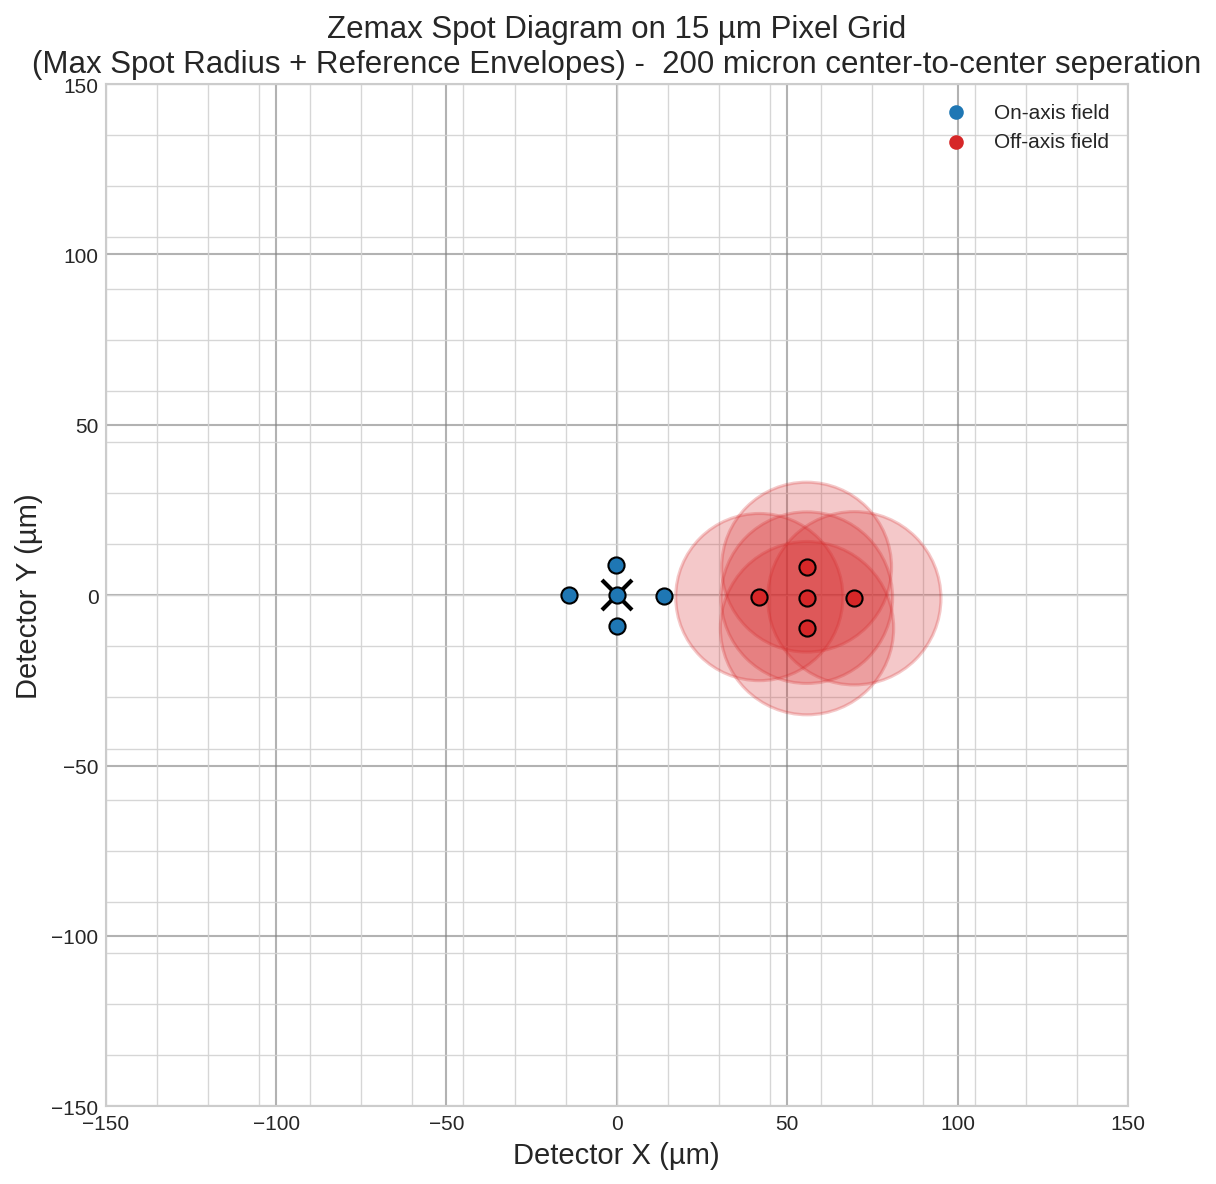

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Rectangle
import matplotlib.ticker as ticker

# ---------------------------------------------------
# Clean axis ticks (coarser than pixel grid)
# ---------------------------------------------------
tick_spacing = 50  # µm (you can also try 75 or 100)

ax.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
ax.yaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))

ax.xaxis.set_minor_locator(ticker.MultipleLocator(15))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(15))
# ---------------------------------------------------
# Image coordinates (mm)
# ---------------------------------------------------
x = np.array([
    43.7685354,
    43.7824833,
    43.7545847,
    43.7684548,
    43.7686140,
    43.8243094,
    43.8382451,
    43.8103705,
    43.8242476,
    43.8243690
])

y = np.array([
    -21.5025194,
    -21.5026998,
    -21.5023370,
    -21.4935542,
    -21.5114734,
    -21.5032289,
    -21.5034012,
    -21.5030545,
    -21.4942691,
    -21.5121775
])

# ---------------------------------------------------
# Max Spot Radius (µm)
# ---------------------------------------------------
r_um = np.array([
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    25.17669069,
    25.4297197,
    24.5272603,
    24.9279621,
    25.4230401
])

# ---------------------------------------------------
# Field center = first 5 points
# ---------------------------------------------------
xc = np.mean(x[:5])
yc = np.mean(y[:5])

dx = (x - xc) * 1000  # µm
dy = (y - yc) * 1000

# ---------------------------------------------------
# Figure
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(8,8), dpi=150)

# ---------------------------------------------------
# Pixel grid (15 µm)
# ---------------------------------------------------
pixel = 15
grid_lim = 150

for i in range(-grid_lim, grid_lim, pixel):
    for j in range(-grid_lim, grid_lim, pixel):
        ax.add_patch(Rectangle(
            (i, j),
            pixel,
            pixel,
            facecolor='none',
            edgecolor='lightgray',
            linewidth=0.6,
            alpha=0.7
        ))
# ---------------------------------------------------
# Plot spots using MAX radius
# ---------------------------------------------------
for i in range(len(x)):
    color = 'tab:blue' if i < 5 else 'tab:red'

    ax.scatter(dx[i], dy[i],
               s=60,
               color=color,
               edgecolor='black',
               zorder=3)

    if r_um[i] > 0:
        ax.add_patch(Circle(
            (dx[i], dy[i]),
            r_um[i],
            facecolor=color,
            alpha=0.25,
            edgecolor=color,
            linewidth=1.5
        ))

# ---------------------------------------------------
# Field center
# ---------------------------------------------------
ax.plot(0, 0, 'kx', markersize=14, mew=2)

# ---------------------------------------------------
# Formatting
# ---------------------------------------------------
ax.set_aspect('equal', adjustable='box')

ax.set_xlim(-grid_lim, grid_lim)
ax.set_ylim(-grid_lim, grid_lim)

ax.set_xlabel('Detector X (µm)', fontsize=14)
ax.set_ylabel('Detector Y (µm)', fontsize=14)

ax.set_title(
    'Zemax Spot Diagram on 15 µm Pixel Grid\n'
    '(Max Spot Radius + Reference Envelopes) -  200 micron center-to-center seperation',
    fontsize=15
)

# Legend proxy
ax.scatter([], [], color='tab:blue', label='On-axis field')
ax.scatter([], [], color='tab:red', label='Off-axis field')

ax.legend(loc='upper right')

ax.grid(which='major', color='gray', linewidth=1.0, alpha=0.6)
ax.grid(which='minor', color='lightgray', linewidth=0.6, alpha=0.5)

plt.tight_layout()
plt.show()


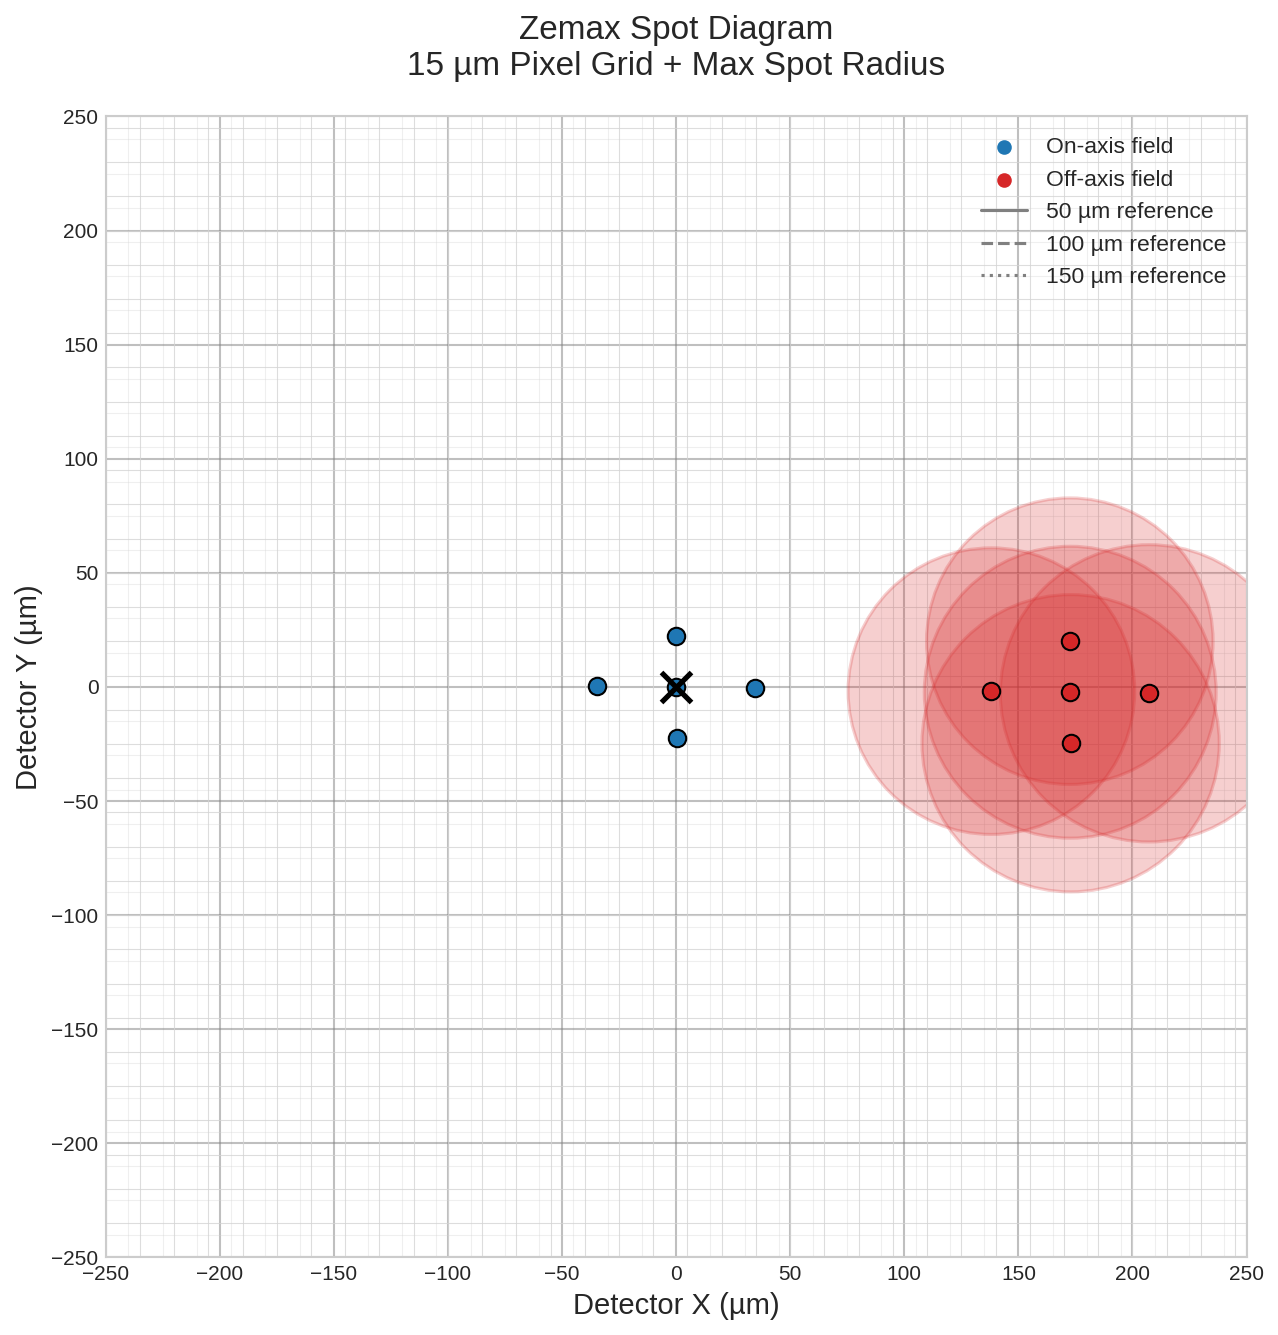

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.patches import Circle, Rectangle

# ---------------------------------------------------
# UPDATED Image coordinates (mm)
# ---------------------------------------------------
x = np.array([
    43.7685354,
    43.8030850,
    43.7339844,
    43.7683296,
    43.7687395,

    43.9412666,
    43.9758071,
    43.9067239,
    43.9410833,
    43.9414477
])

y = np.array([
    -21.5025194,
    -21.5029750,
    -21.5020684,
    -21.4801520,
    -21.5248805,

    -21.5048430,
    -21.5053214,
    -21.5043691,
    -21.4824806,
    -21.5271991
])

# ---------------------------------------------------
# Max Spot Radius (µm)
# ---------------------------------------------------
r_um = np.array([
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,

    63.9599403,
    65.1384161,
    62.8010472,
    62.7823703,
    65.1424192
])

# ---------------------------------------------------
# Field center = first 5 points
# ---------------------------------------------------
xc = np.mean(x[:5])
yc = np.mean(y[:5])

dx = (x - xc) * 1000  # mm → µm
dy = (y - yc) * 1000

# ---------------------------------------------------
# Figure setup
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(9,9), dpi=150)

# ---------------------------------------------------
# Pixel grid (15 µm pixels)
# ---------------------------------------------------
pixel = 15
grid_lim = 250

for i in range(-grid_lim, grid_lim + pixel, pixel):
    for j in range(-grid_lim, grid_lim + pixel, pixel):
        ax.add_patch(Rectangle(
            (i, j),
            pixel,
            pixel,
            facecolor='none',
            edgecolor='lightgray',
            linewidth=0.5,
            alpha=0.5
        ))

# ---------------------------------------------------
# Plot spots using MAX radius
# ---------------------------------------------------
for i in range(len(x)):

    color = 'tab:blue' if i < 5 else 'tab:red'

    # spot center
    ax.scatter(
        dx[i],
        dy[i],
        s=70,
        color=color,
        edgecolor='black',
        zorder=5
    )

    # max spot radius
    if r_um[i] > 0:
        ax.add_patch(Circle(
            (dx[i], dy[i]),
            r_um[i],
            facecolor=color,
            edgecolor=color,
            linewidth=1.5,
            alpha=0.22
        ))

# ---------------------------------------------------
# Field center
# ---------------------------------------------------
ax.plot(
    0, 0,
    marker='x',
    markersize=14,
    markeredgewidth=2.5,
    color='black',
    zorder=6
)

# ---------------------------------------------------
# Axes formatting
# ---------------------------------------------------
ax.set_aspect('equal', adjustable='box')

ax.set_xlim(-grid_lim, grid_lim)
ax.set_ylim(-grid_lim, grid_lim)

# Major ticks every 50 µm
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))

# Minor ticks every pixel
ax.xaxis.set_minor_locator(ticker.MultipleLocator(pixel))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(pixel))

# Grid hierarchy
ax.grid(which='major', color='gray', linewidth=1.0, alpha=0.5)
ax.grid(which='minor', color='lightgray', linewidth=0.5, alpha=0.35)

# Labels
ax.set_xlabel('Detector X (µm)', fontsize=14)
ax.set_ylabel('Detector Y (µm)', fontsize=14)

ax.set_title(
    'Zemax Spot Diagram\n'
    '15 µm Pixel Grid + Max Spot Radius',
    fontsize=16,
    pad=20
)

# Legend proxies
ax.scatter([], [], color='tab:blue', label='On-axis field')
ax.scatter([], [], color='tab:red', label='Off-axis field')

ax.plot([], [], '-', color='gray', label='50 µm reference')
ax.plot([], [], '--', color='gray', label='100 µm reference')
ax.plot([], [], ':', color='gray', label='150 µm reference')

ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

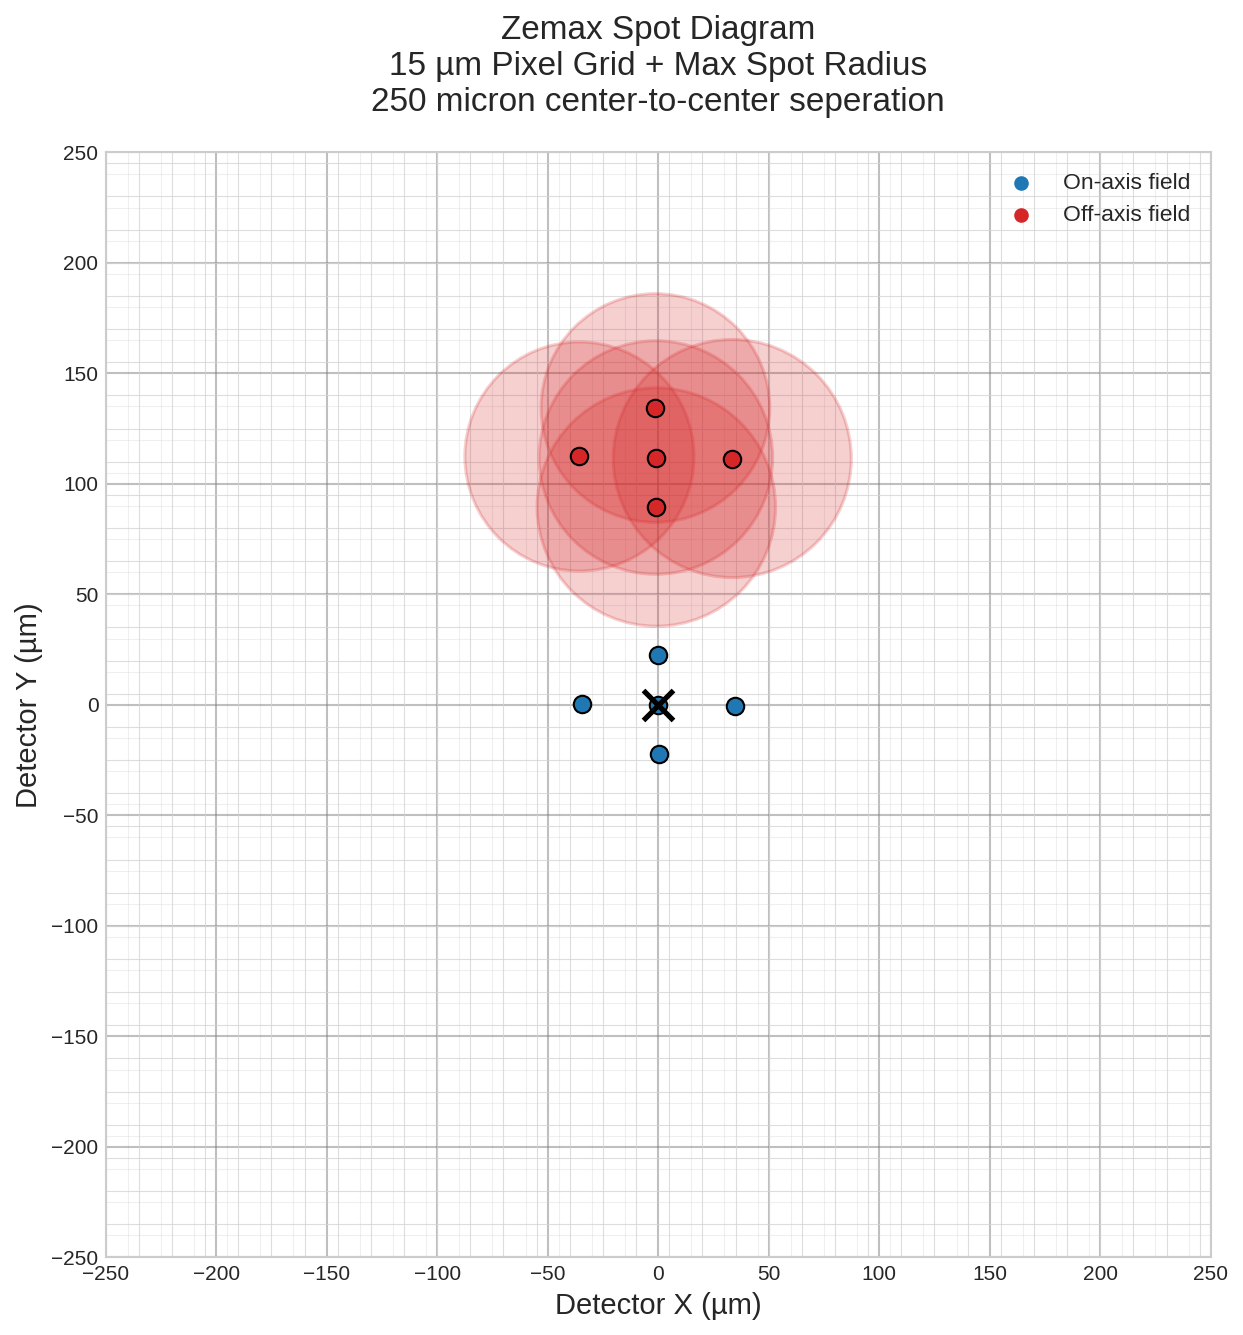

In [38]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.patches import Circle, Rectangle

# ---------------------------------------------------
# UPDATED Image coordinates (mm)
# ---------------------------------------------------
x = np.array([
    43.7685354,
    43.8030850,
    43.7339844,
    43.7683296,
    43.7687395,

    43.7674889,
    43.8020604,
    43.7329159,
    43.7672743,
    43.7677016
])

y = np.array([
    -21.5025194,
    -21.5029750,
    -21.5020684,
    -21.4801520,
    -21.5248805,

    -21.3906216,
    -21.3910819,
    -21.3901662,
    -21.3682245,
    -21.4130131
])

# ---------------------------------------------------
# Max Spot Radius (µm)
# ---------------------------------------------------
r_um = np.array([
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,

    52.8298605,
    53.8511413,
    51.8255892,
    51.7249035,
    53.9344819
])

# ---------------------------------------------------
# Field center = first 5 points
# ---------------------------------------------------
xc = np.mean(x[:5])
yc = np.mean(y[:5])

dx = (x - xc) * 1000  # mm → µm
dy = (y - yc) * 1000

# ---------------------------------------------------
# Figure setup
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(9,9), dpi=150)

# ---------------------------------------------------
# Pixel grid (15 µm pixels)
# ---------------------------------------------------
pixel = 15
grid_lim = 250

for i in range(-grid_lim, grid_lim + pixel, pixel):
    for j in range(-grid_lim, grid_lim + pixel, pixel):
        ax.add_patch(Rectangle(
            (i, j),
            pixel,
            pixel,
            facecolor='none',
            edgecolor='lightgray',
            linewidth=0.5,
            alpha=0.5
        ))

# ---------------------------------------------------
# Plot spots using MAX radius
# ---------------------------------------------------
for i in range(len(x)):

    color = 'tab:blue' if i < 5 else 'tab:red'

    # spot center
    ax.scatter(
        dx[i],
        dy[i],
        s=70,
        color=color,
        edgecolor='black',
        zorder=5
    )

    # max spot radius circle
    if r_um[i] > 0:
        ax.add_patch(Circle(
            (dx[i], dy[i]),
            r_um[i],
            facecolor=color,
            edgecolor=color,
            linewidth=1.5,
            alpha=0.22
        ))

# ---------------------------------------------------
# Field center marker
# ---------------------------------------------------
ax.plot(
    0, 0,
    marker='x',
    markersize=14,
    markeredgewidth=2.5,
    color='black',
    zorder=6
)

# ---------------------------------------------------
# Axes formatting
# ---------------------------------------------------
ax.set_aspect('equal', adjustable='box')

ax.set_xlim(-grid_lim, grid_lim)
ax.set_ylim(-grid_lim, grid_lim)

# Major ticks every 50 µm
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))

# Minor ticks every pixel
ax.xaxis.set_minor_locator(ticker.MultipleLocator(pixel))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(pixel))

# Grid hierarchy
ax.grid(which='major', color='gray', linewidth=1.0, alpha=0.5)
ax.grid(which='minor', color='lightgray', linewidth=0.5, alpha=0.35)

# Labels
ax.set_xlabel('Detector X (µm)', fontsize=14)
ax.set_ylabel('Detector Y (µm)', fontsize=14)

ax.set_title(
    'Zemax Spot Diagram\n'
    '15 µm Pixel Grid + Max Spot Radius\n'
    '250 micron center-to-center seperation',
    fontsize=16,
    pad=20
)

# Legend proxies
ax.scatter([], [], color='tab:blue', label='On-axis field')
ax.scatter([], [], color='tab:red', label='Off-axis field')
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

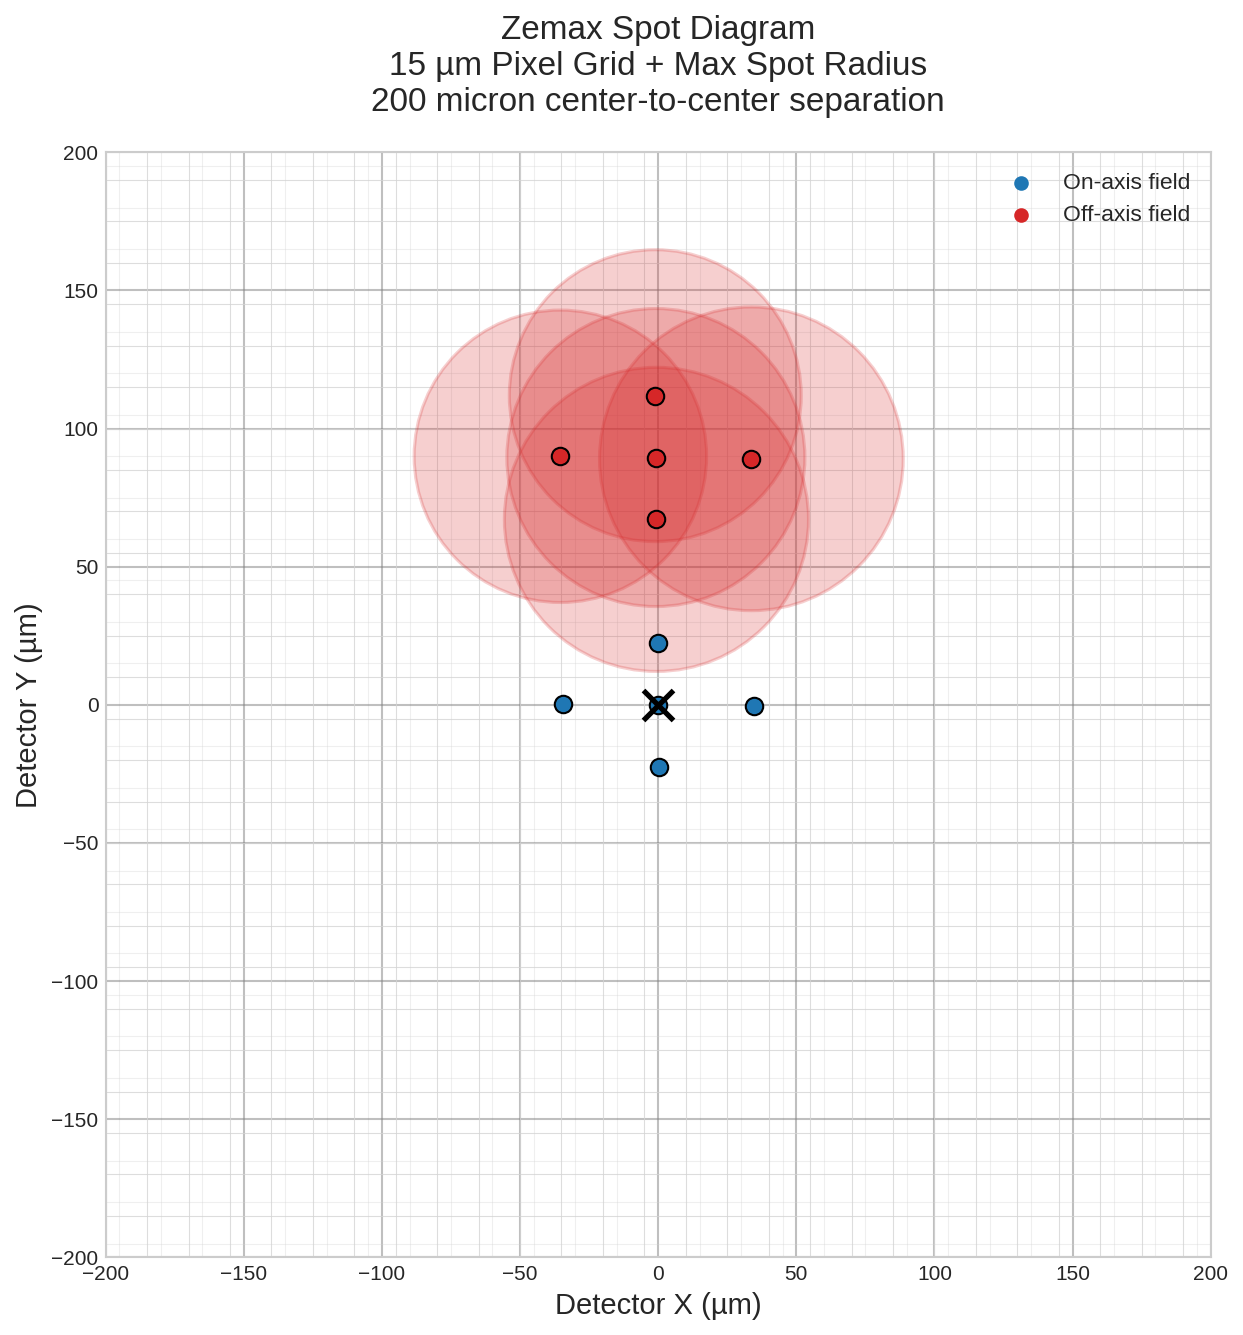

In [39]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.patches import Circle, Rectangle

# ---------------------------------------------------
# UPDATED Image coordinates (mm)
# ---------------------------------------------------
x = np.array([
    43.7685354,
    43.8030850,
    43.7339844,
    43.7683296,
    43.7687395,

    43.7677016,
    43.8022689,
    43.7331330,
    43.7674889,
    43.7679127
])

y = np.array([
    -21.5025194,
    -21.5029750,
    -21.5020684,
    -21.4801520,
    -21.5248805,

    -21.4130131,
    -21.4134724,
    -21.4125586,
    -21.3906216,
    -21.4353987
])

# ---------------------------------------------------
# Max Spot Radius (µm)
# ---------------------------------------------------
r_um = np.array([
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,

    53.9344819,
    54.9670357,
    52.9191541,
    52.8298605,
    55.0390212
])

# ---------------------------------------------------
# Field center = first 5 points
# ---------------------------------------------------
xc = np.mean(x[:5])
yc = np.mean(y[:5])

dx = (x - xc) * 1000  # mm → µm
dy = (y - yc) * 1000

# ---------------------------------------------------
# Figure setup
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(9,9), dpi=150)

# ---------------------------------------------------
# Pixel grid (15 µm pixels)
# ---------------------------------------------------
pixel = 15
grid_lim = 200

for i in range(-grid_lim, grid_lim + pixel, pixel):
    for j in range(-grid_lim, grid_lim + pixel, pixel):
        ax.add_patch(Rectangle(
            (i, j),
            pixel,
            pixel,
            facecolor='none',
            edgecolor='lightgray',
            linewidth=0.5,
            alpha=0.5
        ))

# ---------------------------------------------------
# Plot spots using MAX radius
# ---------------------------------------------------
for i in range(len(x)):

    color = 'tab:blue' if i < 5 else 'tab:red'

    # Spot center
    ax.scatter(
        dx[i],
        dy[i],
        s=70,
        color=color,
        edgecolor='black',
        zorder=5
    )

    # Max spot radius circle
    if r_um[i] > 0:
        ax.add_patch(Circle(
            (dx[i], dy[i]),
            r_um[i],
            facecolor=color,
            edgecolor=color,
            linewidth=1.5,
            alpha=0.22
        ))

# ---------------------------------------------------
# Field center marker
# ---------------------------------------------------
ax.plot(
    0, 0,
    marker='x',
    markersize=14,
    markeredgewidth=2.5,
    color='black',
    zorder=6
)

# ---------------------------------------------------
# Axes formatting
# ---------------------------------------------------
ax.set_aspect('equal', adjustable='box')

ax.set_xlim(-grid_lim, grid_lim)
ax.set_ylim(-grid_lim, grid_lim)

# Major ticks every 50 µm
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))

# Minor ticks every pixel
ax.xaxis.set_minor_locator(ticker.MultipleLocator(pixel))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(pixel))

# Grid hierarchy
ax.grid(which='major', color='gray', linewidth=1.0, alpha=0.5)
ax.grid(which='minor', color='lightgray', linewidth=0.5, alpha=0.35)

# Labels
ax.set_xlabel('Detector X (µm)', fontsize=14)
ax.set_ylabel('Detector Y (µm)', fontsize=14)

ax.set_title(
    'Zemax Spot Diagram\n'
    '15 µm Pixel Grid + Max Spot Radius\n'
    '200 micron center-to-center separation',
    fontsize=16,
    pad=20
)

# Legend proxies
ax.scatter([], [], color='tab:blue', label='On-axis field')
ax.scatter([], [], color='tab:red', label='Off-axis field')


ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()


##

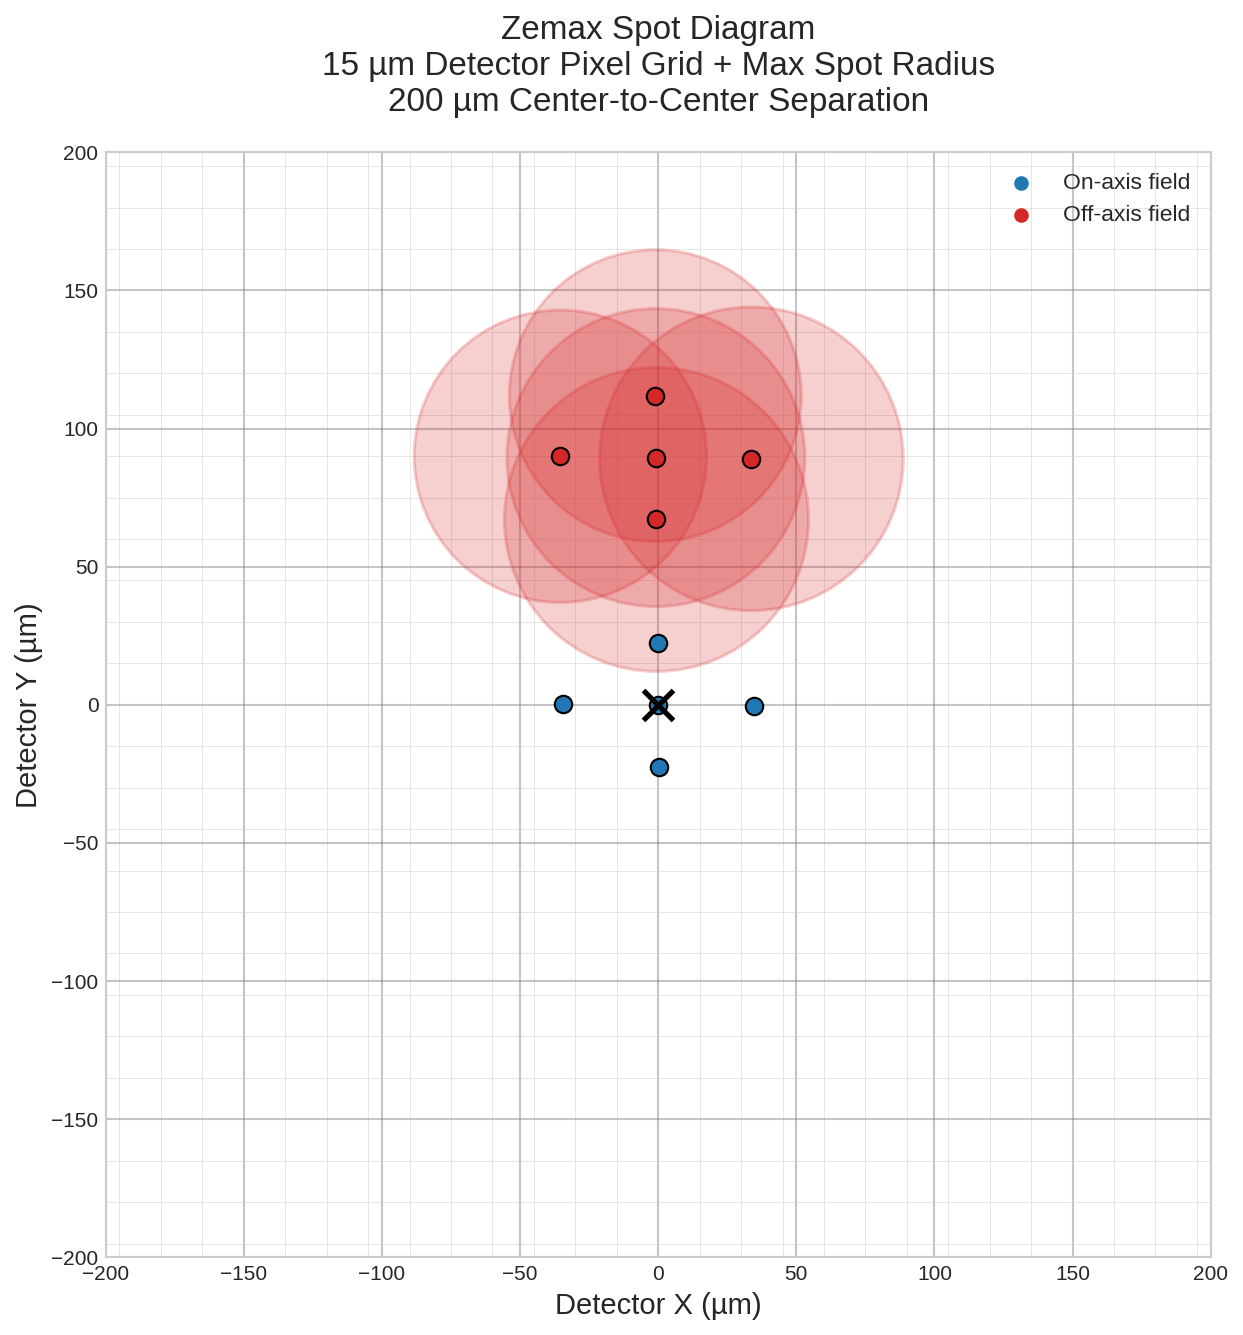

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.patches import Circle

# ---------------------------------------------------
# UPDATED Image coordinates (mm)
# ---------------------------------------------------
x = np.array([
    43.7685354,
    43.8030850,
    43.7339844,
    43.7683296,
    43.7687395,

    43.7677016,
    43.8022689,
    43.7331330,
    43.7674889,
    43.7679127
])

y = np.array([
    -21.5025194,
    -21.5029750,
    -21.5020684,
    -21.4801520,
    -21.5248805,

    -21.4130131,
    -21.4134724,
    -21.4125586,
    -21.3906216,
    -21.4353987
])

# ---------------------------------------------------
# Max Spot Radius (µm)
# ---------------------------------------------------
r_um = np.array([
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,

    53.9344819,
    54.9670357,
    52.9191541,
    52.8298605,
    55.0390212
])

# ---------------------------------------------------
# Field center = first 5 points
# ---------------------------------------------------
xc = np.mean(x[:5])
yc = np.mean(y[:5])

dx = (x - xc) * 1000  # mm → µm
dy = (y - yc) * 1000

# ---------------------------------------------------
# Figure setup
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(9,9), dpi=150)

# ---------------------------------------------------
# Detector parameters
# ---------------------------------------------------
pixel = 15
grid_lim = 200

# ---------------------------------------------------
# Plot spots using MAX radius
# ---------------------------------------------------
for i in range(len(x)):

    color = 'tab:blue' if i < 5 else 'tab:red'

    # Spot center
    ax.scatter(
        dx[i],
        dy[i],
        s=70,
        color=color,
        edgecolor='black',
        zorder=5
    )

    # Max spot radius
    if r_um[i] > 0:
        ax.add_patch(Circle(
            (dx[i], dy[i]),
            r_um[i],
            facecolor=color,
            edgecolor=color,
            linewidth=1.5,
            alpha=0.22
        ))

# ---------------------------------------------------
# Field center marker
# ---------------------------------------------------
ax.plot(
    0, 0,
    marker='x',
    markersize=14,
    markeredgewidth=2.5,
    color='black',
    zorder=6
)

# ---------------------------------------------------
# Axes formatting
# ---------------------------------------------------
ax.set_aspect('equal', adjustable='box')

ax.set_xlim(-grid_lim, grid_lim)
ax.set_ylim(-grid_lim, grid_lim)

# Major ticks every 50 µm
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))

# Minor ticks every 15 µm pixel
ax.xaxis.set_minor_locator(ticker.MultipleLocator(pixel))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(pixel))

# Grid styling
ax.grid(
    which='major',
    color='gray',
    linewidth=1.0,
    alpha=0.45
)

ax.grid(
    which='minor',
    color='lightgray',
    linewidth=0.45,
    alpha=0.6
)

# Labels
ax.set_xlabel('Detector X (µm)', fontsize=14)
ax.set_ylabel('Detector Y (µm)', fontsize=14)

ax.set_title(
    'Zemax Spot Diagram\n'
    '15 µm Detector Pixel Grid + Max Spot Radius\n'
    '200 µm Center-to-Center Separation',
    fontsize=16,
    pad=20
)

# Legend
ax.scatter([], [], color='tab:blue', label='On-axis field')
ax.scatter([], [], color='tab:red', label='Off-axis field')

ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

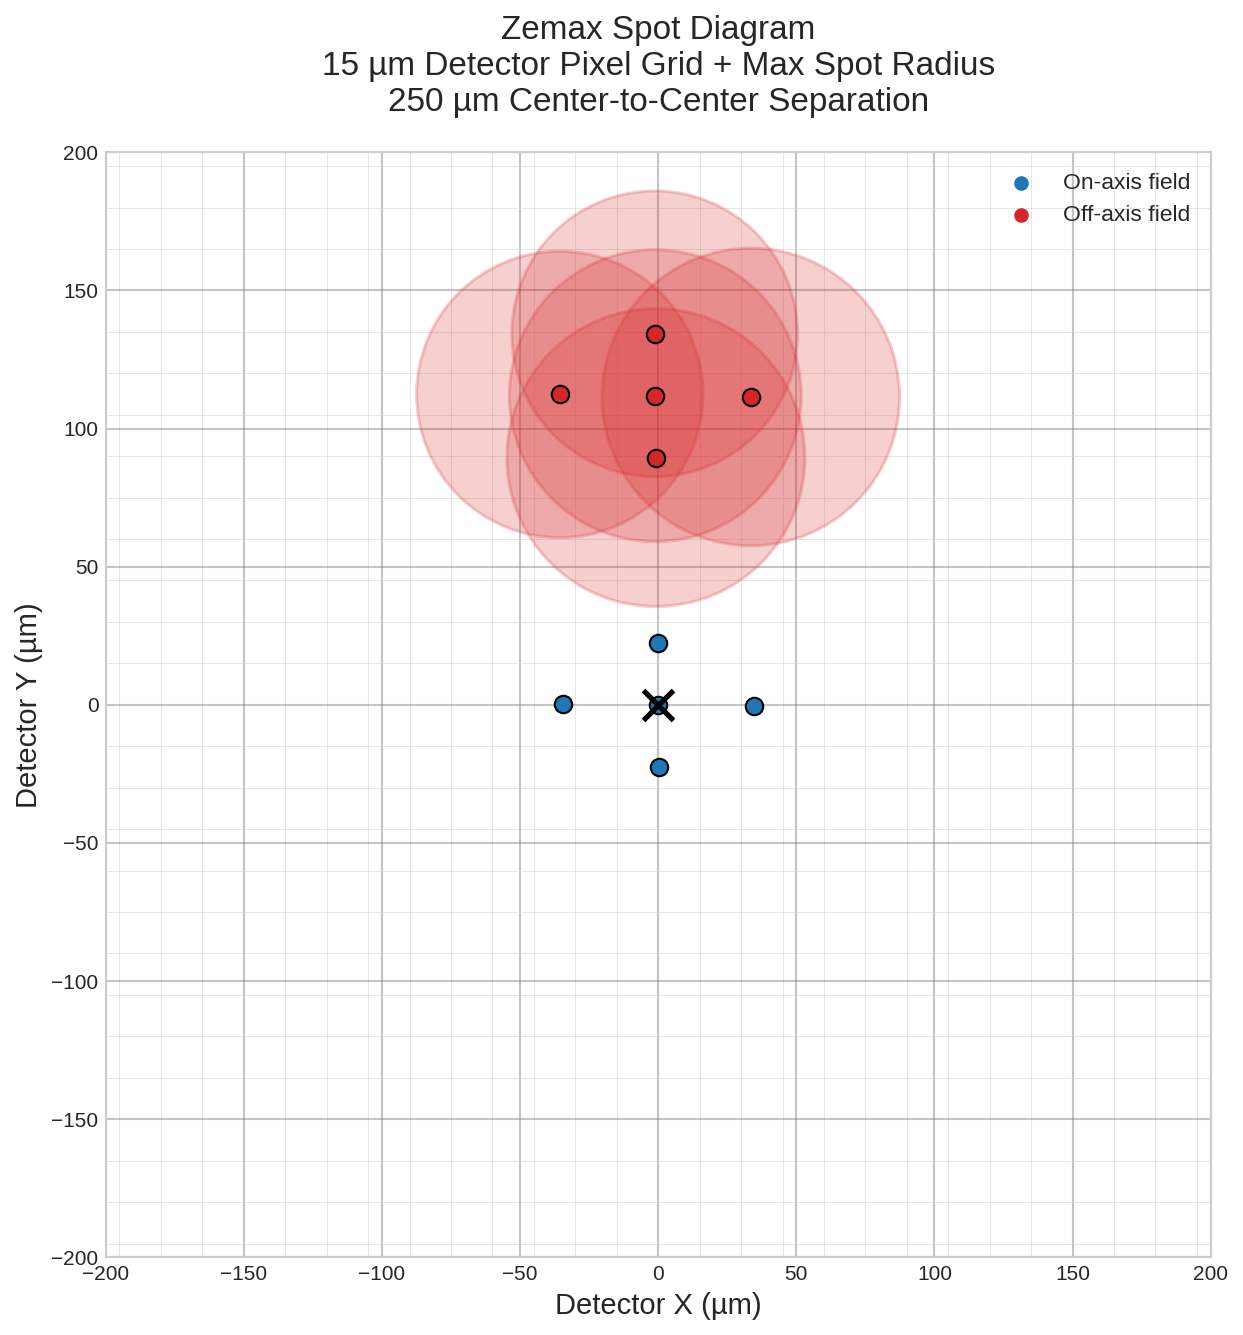

In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.patches import Circle

# ---------------------------------------------------
# UPDATED Image coordinates (mm)
# ---------------------------------------------------
x = np.array([
    43.7685354,
    43.8030850,
    43.7339844,
    43.7683296,
    43.7687395,

    43.7674889,
    43.8020604,
    43.7329159,
    43.7672743,
    43.7677016
])

y = np.array([
    -21.5025194,
    -21.5029750,
    -21.5020684,
    -21.4801520,
    -21.5248805,

    -21.3906216,
    -21.3910819,
    -21.3901662,
    -21.3682245,
    -21.4130131
])

# ---------------------------------------------------
# Max Spot Radius (µm)
# ---------------------------------------------------
r_um = np.array([
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,

    52.8298605,
    53.8511413,
    51.8255892,
    51.7249035,
    53.9344819
])

# ---------------------------------------------------
# Field center = first 5 points
# ---------------------------------------------------
xc = np.mean(x[:5])
yc = np.mean(y[:5])

dx = (x - xc) * 1000  # mm → µm
dy = (y - yc) * 1000

# ---------------------------------------------------
# Figure setup
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(9,9), dpi=150)

# ---------------------------------------------------
# Detector parameters
# ---------------------------------------------------
pixel = 15
grid_lim = 200

# ---------------------------------------------------
# Plot spots using MAX radius
# ---------------------------------------------------
for i in range(len(x)):

    color = 'tab:blue' if i < 5 else 'tab:red'

    # Spot center
    ax.scatter(
        dx[i],
        dy[i],
        s=70,
        color=color,
        edgecolor='black',
        zorder=5
    )

    # Max spot radius
    if r_um[i] > 0:
        ax.add_patch(Circle(
            (dx[i], dy[i]),
            r_um[i],
            facecolor=color,
            edgecolor=color,
            linewidth=1.5,
            alpha=0.22
        ))

# ---------------------------------------------------
# Field center marker
# ---------------------------------------------------
ax.plot(
    0, 0,
    marker='x',
    markersize=14,
    markeredgewidth=2.5,
    color='black',
    zorder=6
)

# ---------------------------------------------------
# Axes formatting
# ---------------------------------------------------
ax.set_aspect('equal', adjustable='box')

ax.set_xlim(-grid_lim, grid_lim)
ax.set_ylim(-grid_lim, grid_lim)

# Major ticks every 50 µm
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))

# Minor ticks every detector pixel
ax.xaxis.set_minor_locator(ticker.MultipleLocator(pixel))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(pixel))

# Grid styling
ax.grid(
    which='major',
    color='gray',
    linewidth=1.0,
    alpha=0.45
)

ax.grid(
    which='minor',
    color='lightgray',
    linewidth=0.45,
    alpha=0.6
)

# Labels
ax.set_xlabel('Detector X (µm)', fontsize=14)
ax.set_ylabel('Detector Y (µm)', fontsize=14)

ax.set_title(
    'Zemax Spot Diagram\n'
    '15 µm Detector Pixel Grid + Max Spot Radius\n'
    '250 µm Center-to-Center Separation',
    fontsize=16,
    pad=20
)

# Legend
ax.scatter([], [], color='tab:blue', label='On-axis field')
ax.scatter([], [], color='tab:red', label='Off-axis field')

ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()